Okay, ya tenemos filtrados y clasificados 300.000 post con titulo + comentario de 4 subreddits distintos.

- Target -> Overwatch.corpus
- Hard negative -> GlobalOffensive.corpus
- Medium negative -> gaming.corpus
- Soft negative -> NoStupidQuestions.corpus

A continuación, vamos a montar nuestro baseline utilizando analisis por pares con la libreria 'chi2', para discernir las palabras mas características de nuestro target. 

También vamos a medir como de bien funciona este algoritmo de clasificacion.

In [2]:
import pandas as pd
import re
import html

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"\[deleted\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\[removed\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

BASE = "D:\\TFM\\data\\"
files = {
    "overwatch": "Overwatch.corpus\\overwatch_posts_final.parquet",
    "gaming": "gaming.corpus\\gaming_posts_final.parquet",
    "hard_neg": "GlobalOffensive.corpus\\GlobalOffensive_posts_final.parquet",
    "soft_neg": "NoStupidQuestions.corpus\\NoStupidQuestions_posts_final.parquet",
}

dfs = {}
for key, fname in files.items():
    df = pd.read_parquet(BASE + fname)
    df["clean_text"] = df["full_text"].apply(clean_text)
    dfs[key] = df
    print(f"{key:10s} -> {len(df):,} filas | vacíos tras limpieza: {(df['clean_text']=='').sum()}")

overwatch  -> 300,000 filas | vacíos tras limpieza: 327
gaming     -> 300,000 filas | vacíos tras limpieza: 911
hard_neg   -> 300,000 filas | vacíos tras limpieza: 356
soft_neg   -> 300,000 filas | vacíos tras limpieza: 22


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_selection import chi2
import numpy as np

custom_stopwords = {
    "like", "just", "really", "also", "get", "got", "would", "could",
    "one", "even", "much", "still", "make", "made", "know", "think",
    "https", "http", "www", "reddit", "com",
    "im", "ive", "dont", "didnt", "isnt", "youre", "theyre",
}
extended_stopwords = list(ENGLISH_STOP_WORDS.union(custom_stopwords))

def chi2_vs_negative(df_target, df_negative, ngram_range=(1, 2), min_df=5, max_df=0.6):
    df_pair = pd.concat([df_target, df_negative], ignore_index=True)
    y = np.array([1] * len(df_target) + [0] * len(df_negative))
    vec = TfidfVectorizer(stop_words=extended_stopwords, ngram_range=ngram_range, min_df=min_df, max_df=max_df)
    X = vec.fit_transform(df_pair["clean_text"])
    scores, pvals = chi2(X, y)
    terms = np.array(vec.get_feature_names_out())
    return pd.DataFrame({"term": terms, "chi2": scores, "pval": pvals}).set_index("term")

res_soft   = chi2_vs_negative(dfs["overwatch"], dfs["soft_neg"])
res_medium = chi2_vs_negative(dfs["overwatch"], dfs["gaming"])
res_hard   = chi2_vs_negative(dfs["overwatch"], dfs["hard_neg"])

print("Vocabulario por comparación:", len(res_soft), len(res_medium), len(res_hard))

Vocabulario por comparación: 327279 272587 301928


In [4]:
common_terms = res_soft.index.intersection(res_medium.index).intersection(res_hard.index)
print(f"Términos presentes en las tres comparaciones: {len(common_terms):,}")

combined = pd.DataFrame({
    "chi2_soft":   res_soft.loc[common_terms, "chi2"],
    "chi2_medium": res_medium.loc[common_terms, "chi2"],
    "chi2_hard":   res_hard.loc[common_terms, "chi2"],
    "pval_soft":   res_soft.loc[common_terms, "pval"],
    "pval_medium": res_medium.loc[common_terms, "pval"],
    "pval_hard":   res_hard.loc[common_terms, "pval"],
})

combined["chi2_min"] = combined[["chi2_soft", "chi2_medium", "chi2_hard"]].min(axis=1)

significativo = (
    (combined["pval_soft"] < 0.05) &
    (combined["pval_medium"] < 0.05) &
    (combined["pval_hard"] < 0.05)
)

final_terms = combined[significativo].sort_values("chi2_min", ascending=False)
print(f"Términos finales robustos: {len(final_terms):,}")
final_terms.head(40)

Términos presentes en las tres comparaciones: 203,574
Términos finales robustos: 14,605


,chi2_soft,chi2_medium,chi2_hard,pval_soft,pval_medium,pval_hard,chi2_min
term,,,,,,,
overwatch,5166.448022,4407.026594,4256.237681,0.000000e+00,0.000000e+00,0.000000e+00,4256.237681
mercy,2470.540464,2329.693658,2460.875160,0.000000e+00,0.000000e+00,0.000000e+00,2329.693658
blizzard,2025.787646,1844.434160,2027.551747,0.000000e+00,0.000000e+00,0.000000e+00,1844.434160
potg,1851.613376,1826.578633,1845.180473,0.000000e+00,0.000000e+00,0.000000e+00,1826.578633
moira,1758.641436,1745.608960,1758.491402,0.000000e+00,0.000000e+00,0.000000e+00,1745.608960
genji,1689.221571,1642.737011,1686.503300,0.000000e+00,0.000000e+00,0.000000e+00,1642.737011
hanzo,1630.227943,1586.763431,1631.708367,0.000000e+00,0.000000e+00,0.000000e+00,1586.763431
hero,1889.395722,1516.570150,1857.140282,0.000000e+00,0.000000e+00,0.000000e+00,1516.570150
va,1462.014895,1392.139485,1474.513722,0.000000e+00,1.072850e-304,0.000000e+00,1392.139485


In [5]:
final_terms.to_parquet("D:\\TFM\\data\\chi2_overwatch_terms.parquet")

Parece que el top 40 de la lista de términos robustos en esta comparativa es bastante solido!

Casi toda la terminología que encontramos es totalmente específica a overwatch.

Mediante las combinaciones de las confrontaciones del test chi2 se nos ha quedado un ranking bastante sólido. Con un total de 203,574 términos presentes en las tres comparaciones y 14,605 términos finales robustos

Ahora, para realizar evaluaciones con la máxima veracidad posible, necesitamos crear un conjunto de datos clasificados que sea nuestro 'gold standard'. 

Si asumimos que todos los posts del subreddit de Overwatch son de Overwatch, estamos haciendo una simplificación con un posible ruido peligroso, ya que es totalmente posible que en subreddit de Overwatch se hablen de otros temas como alguien que simplemente muestre en fotos su setup de ordenador por ejemplo. 

Si ejecutamos el algoritmo directamente sobre datos etiquetados solo por subreddit, y calculamos métricas contra esa etiqueta, estaremos midiendo que tan bien predecimos un subreddit de origen, pero nosotros queremos añadirle un extra, queremos predecir de que tema esta hablando ese texto. Son dos cosas distintas (aun que a mi parecer bastante parecidas), pero para ser totalmente rigurosos debemos cuantificar estas diferencias.

Es interesante la obtencion de este gold set para los casos frontera, pero también se podría pensar  que esos casos frontera van a ser outliers y no la norma.

Es dificil que por ejemplo en el subreddit de gaming se este hablando del overwatch sin absolutamente ningua referencia o combinacion de referencias a los terminos sacados por la combinacion de chi2. Linguisticamente el lector de ese post no tendría forma alguna de adivinar que esa persona esta hablando de overwatch. 

Lo que si es cierto es que el etiquetado de los post de gaming como 'no hablan de overwatch' sería totalmente erroneo, ya que es un subreddit en particular en el que SI que se puede hablar de overwatch. Sin embargo en subreddits de csgo y nostupidquestions, el etiquetado de que no se esta hablando de overwatch es bastante fiable, por tanto esos subreddits si que tendría sentido clasificarlos como negativos.

De todas maneras esto es un hipotesis no probada, creo que es interesante crear ese gold standard para ver como se comporta el algoritmo con casos tan claros

Para la creación de este 'gold standard' o 'gold set', vamos a utilizar técnicas hibridas, en las cuales vamos a hacer uso de nuestras métricas chi2 para hacer un filtrado general, para luego revisar de manera mas sencilla manualmente esos etiquetados.

Diseño de muestreo:

- r/Overwatch: muestra aleatoria simple — aquí confiamos más en la etiqueta de subreddit, pero incluimos algunos para verificar que no son casos "fuera de tema" (setups, memes sin texto, etc.)

- r/gaming: aplicamos score_text a todo el corpus, y muestreamos por cuartiles/buckets de score (score=0, score bajo, score medio, score alto) — esto es lo que pone a la hipótesis de forma directa y cubre la zona gris para el tuning del umbral

- r/GlobalOffensive: muestra aleatoria — negativo de control "duro" (mismo dominio shooter, pero specific-vocab distinto)

- NoStupidQuestions: muestra aleatoria — negativo de control "fácil"

In [6]:
import pandas as pd
import numpy as np

# Reconstruir la función de score con el vocabulario guardado
final_terms = pd.read_parquet("D:\\TFM\\data\\chi2_overwatch_terms.parquet")
term_weights = final_terms["chi2_min"].to_dict()

import re
sorted_terms = sorted(term_weights.keys(), key=len, reverse=True)
pattern = re.compile(r"\b(" + "|".join(re.escape(t) for t in sorted_terms) + r")\b")

def score_text(text, weights=term_weights, min_words_norm=5):
    matches = pattern.findall(text)
    if not matches:
        return 0.0, []
    raw_score = sum(weights[m] for m in matches)
    n_words = max(len(text.split()), min_words_norm)
    return raw_score / n_words, matches

# Aplicar a r/gaming
df_gaming = dfs["gaming"].copy()
scores_matches = df_gaming["clean_text"].apply(score_text)
df_gaming["score"] = scores_matches.apply(lambda x: x[0])
df_gaming["matched_terms"] = scores_matches.apply(lambda x: x[1])

print(df_gaming["score"].describe())
print("Posts con score 0:", (df_gaming["score"] == 0).sum())
print("Posts con score > 0:", (df_gaming["score"] > 0).sum())

count    300000.000000
mean         15.191643
std          37.313408
min           0.000000
25%           1.698564
50%           6.698723
75%          17.854235
max        1498.233293
Name: score, dtype: float64
Posts con score 0: 41301
Posts con score > 0: 258699


In [7]:
# Estratificar por buckets de score (solo entre los que tienen score > 0, más el bucket de 0 aparte)
df_gaming_nonzero = df_gaming[df_gaming["score"] > 0].copy()
df_gaming_nonzero["score_bucket"] = pd.qcut(df_gaming_nonzero["score"], q=3, labels=["bajo", "medio", "alto"])

N_PER_BUCKET = 40
sample_zero  = df_gaming[df_gaming["score"] == 0].sample(N_PER_BUCKET, random_state=42)
sample_bajo  = df_gaming_nonzero[df_gaming_nonzero["score_bucket"] == "bajo"].sample(N_PER_BUCKET, random_state=42)
sample_medio = df_gaming_nonzero[df_gaming_nonzero["score_bucket"] == "medio"].sample(N_PER_BUCKET, random_state=42)
sample_alto  = df_gaming_nonzero[df_gaming_nonzero["score_bucket"] == "alto"].sample(N_PER_BUCKET, random_state=42)

gold_gaming = pd.concat([sample_zero, sample_bajo, sample_medio, sample_alto])
gold_gaming["stratum"] = ["gaming_score0"]*N_PER_BUCKET + ["gaming_bajo"]*N_PER_BUCKET + \
                          ["gaming_medio"]*N_PER_BUCKET + ["gaming_alto"]*N_PER_BUCKET

In [8]:
# Muestras del resto de fuentes
N_OW = 100
N_HARD = 60
N_SOFT = 60

gold_ow = dfs["overwatch"].sample(N_OW, random_state=42).copy()
gold_ow["stratum"] = "overwatch"

gold_hard = dfs["hard_neg"].sample(N_HARD, random_state=42).copy()
gold_hard["stratum"] = "hard_negative"

gold_soft = dfs["soft_neg"].sample(N_SOFT, random_state=42).copy()
gold_soft["stratum"] = "soft_negative"

gold_set = pd.concat([gold_ow, gold_gaming, gold_hard, gold_soft], ignore_index=True)
gold_set = gold_set.sample(frac=1, random_state=42).reset_index(drop=True)  # mezclar orden

print(gold_set["stratum"].value_counts())
print(f"\nTotal gold set: {len(gold_set)}")

stratum
overwatch        100
hard_negative     60
soft_negative     60
gaming_bajo       40
gaming_alto       40
gaming_score0     40
gaming_medio      40
Name: count, dtype: int64

Total gold set: 380


En este punto es recomendable exportar a un archivo para etiquetado sin ver los score ni los términos matched del algoritmo, asi evitamos el sesgo de confirmación (tendemos a confirmar lo que el propio algoritmo ya "opina")

In [9]:
# Fichero para etiquetar (ciego, sin score)
gold_set[["id", "full_text", "stratum"]].assign(manual_label="").to_csv(
    "D:\\TFM\\data\\gold_set_to_label.csv", index=False
)

# Fichero de referencia con el score, para cruzar DESPUÉS de etiquetar
gold_set[["id", "score", "matched_terms" if "matched_terms" in gold_set.columns else "id"]].to_csv(
    "D:\\TFM\\data\\gold_set_scores_reference.csv", index=False
)

Okay, una vez tenemos generado nuestro archivo, vamos a pasar a evaluar manualmente los 380 registros, donde:
- 0 va a significar 'no habla de overwatch'
- 1 'si habla de overwatch'
- 2 'no hay contexto suficiente para discernirlo' 
- 3 'texto no usable' (como [deleted by user])

## Evaluación del algoritmo contra Gold Set etiquetado

Ahora vamos a evaluar nuestro algoritmo de scoring contra el gold set que ya ha sido etiquetado manualmente.

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, accuracy_score, roc_auc_score
)
import matplotlib.pyplot as plt

# Cargar gold set etiquetado
gold_labeled = pd.read_csv("D:\\TFM\\data\\gold_set_labeled.csv")

print(f"Total registros en gold set: {len(gold_labeled)}")
print(f"\nDistribución de etiquetas:")
print(gold_labeled["manual_label"].value_counts().sort_index())
print(f"  0 = No habla de Overwatch")
print(f"  1 = Sí habla de Overwatch")
print(f"  2 = Contexto insuficiente")
print(f"  3 = Texto no usable")

Total registros en gold set: 380

Distribución de etiquetas:
manual_label
0    241
1     87
2     15
3     37
Name: count, dtype: int64
  0 = No habla de Overwatch
  1 = Sí habla de Overwatch
  2 = Contexto insuficiente
  3 = Texto no usable


In [11]:
# Reconstruir función de limpieza y scoring con el vocabulario loadado previamente
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"\[deleted\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\[removed\]", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

# Cargar términos finales y crear patrón
final_terms = pd.read_parquet("D:\\TFM\\data\\chi2_overwatch_terms.parquet")
term_weights = final_terms["chi2_min"].to_dict()

sorted_terms = sorted(term_weights.keys(), key=len, reverse=True)
pattern = re.compile(r"\b(" + "|".join(re.escape(t) for t in sorted_terms) + r")\b")

def score_text(text, weights=term_weights, min_words_norm=5):
    text_clean = clean_text(text)
    matches = pattern.findall(text_clean)
    if not matches:
        return 0.0, []
    raw_score = sum(weights[m] for m in matches)
    n_words = max(len(text_clean.split()), min_words_norm)
    return raw_score / n_words, matches

# Aplicar scoring al gold set
scores_matches = gold_labeled["full_text"].apply(score_text)
gold_labeled["score"] = scores_matches.apply(lambda x: x[0])
gold_labeled["matched_terms"] = scores_matches.apply(lambda x: x[1])

print(f"\nEstadísticas de score en gold set:")
print(gold_labeled["score"].describe())


Estadísticas de score en gold set:
count    380.000000
mean      28.627453
std       77.171071
min        0.000000
25%        1.977772
50%        7.311198
75%       22.023891
max      851.247536
Name: score, dtype: float64


In [12]:
# Filtrar casos "usables": solo etiquetas 0 y 1 (excluir 2=contexto insuficiente, 3=no usable)
gold_usable = gold_labeled[gold_labeled["manual_label"].isin([0, 1])].copy()

print(f"Total registros usables: {len(gold_usable)}")
print(f"Distribución de clases en conjunto usable:")
print(f"  Clase 0 (No Overwatch): {(gold_usable['manual_label']==0).sum()}")
print(f"  Clase 1 (Sí Overwatch): {(gold_usable['manual_label']==1).sum()}")

# Variable target
y_true = gold_usable["manual_label"].values

Total registros usables: 328
Distribución de clases en conjunto usable:
  Clase 0 (No Overwatch): 241
  Clase 1 (Sí Overwatch): 87


In [13]:
# Calcular ROC y encontrar umbral óptimo
y_scores = gold_usable["score"].values

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)

# Encontrar umbral óptimo (max F1)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"\nUmbral óptimo (máximo F1): {optimal_threshold:.4f}")
print(f"F1 Score en umbral óptimo: {optimal_f1:.4f}")

ROC-AUC Score: 0.7615

Umbral óptimo (máximo F1): 24.6423
F1 Score en umbral óptimo: 0.5917


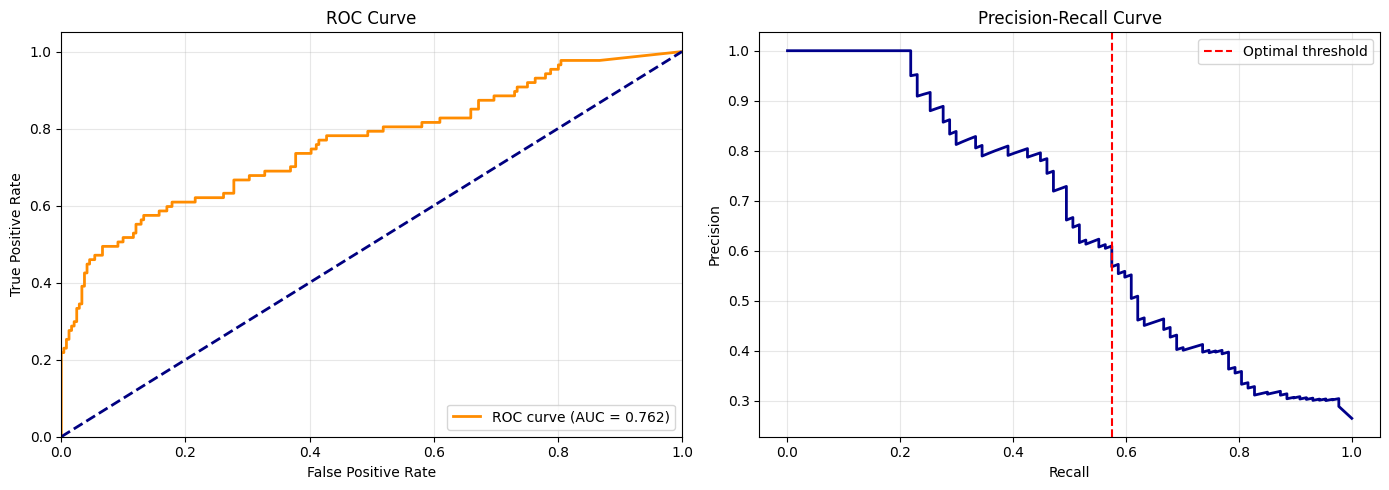

Gráficas generadas.


In [14]:
# Visualizar ROC y Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='darkblue', lw=2)
axes[1].axvline(x=recall[optimal_idx] if optimal_idx < len(recall) else 0.5, color='red', linestyle='--', label=f'Optimal threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficas generadas.")

In [15]:
# Evaluar con diferentes umbrales
def evaluate_threshold(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "f1": f1_score(y_true, y_pred),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }

# Probar múltiples umbrales
thresholds_test = np.arange(0, 1.0, 0.05)
results = [evaluate_threshold(y_true, y_scores, t) for t in thresholds_test]
results_df = pd.DataFrame(results)

print("\n" + "="*100)
print("MÉTRICAS CON DIFERENTES UMBRALES")
print("="*100)
print(results_df.to_string(index=False))

# Mostrar el mejor umbral por F1
best_f1_idx = results_df["f1"].idxmax()
best_result = results_df.loc[best_f1_idx]
print(f"\n{'Mejor umbral (F1):':<20} {best_result['threshold']:.3f}")
print(f"{'Accuracy:':<20} {best_result['accuracy']:.4f}")
print(f"{'Precision:':<20} {best_result['precision']:.4f}")
print(f"{'Recall:':<20} {best_result['recall']:.4f}")
print(f"{'F1 Score:':<20} {best_result['f1']:.4f}")


MÉTRICAS CON DIFERENTES UMBRALES
 threshold  accuracy  precision   recall       f1  tp  fp  tn  fn
      0.00  0.265244   0.265244 1.000000 0.419277  87 241   0   0
      0.05  0.356707   0.289116 0.977011 0.446194  85 209  32   2
      0.10  0.356707   0.289116 0.977011 0.446194  85 209  32   2
      0.15  0.356707   0.289116 0.977011 0.446194  85 209  32   2
      0.20  0.356707   0.289116 0.977011 0.446194  85 209  32   2
      0.25  0.359756   0.290102 0.977011 0.447368  85 208  33   2
      0.30  0.359756   0.290102 0.977011 0.447368  85 208  33   2
      0.35  0.362805   0.291096 0.977011 0.448549  85 207  34   2
      0.40  0.365854   0.292096 0.977011 0.449735  85 206  35   2
      0.45  0.368902   0.293103 0.977011 0.450928  85 205  36   2
      0.50  0.371951   0.294118 0.977011 0.452128  85 204  37   2
      0.55  0.378049   0.296167 0.977011 0.454545  85 202  39   2
      0.60  0.378049   0.296167 0.977011 0.454545  85 202  39   2
      0.65  0.381098   0.297203 0.977011 0

In [16]:
# Análisis detallado con el umbral óptimo
optimal_threshold = best_result["threshold"]
y_pred_optimal = (y_scores >= optimal_threshold).astype(int)

print(f"\n{'='*100}")
print(f"ANÁLISIS DETALLADO CON UMBRAL ÓPTIMO: {optimal_threshold:.3f}")
print(f"{'='*100}")

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_optimal)
print("\nMatriz de Confusión:")
print(f"                Predicción: No Overwatch  |  Predicción: Sí Overwatch")
print(f"Etiqueta: No Overwatch     {cm[0,0]:>6d}           |  {cm[0,1]:>6d}")
print(f"Etiqueta: Sí Overwatch     {cm[1,0]:>6d}           |  {cm[1,1]:>6d}")

# Classification report
print("\n" + classification_report(y_true, y_pred_optimal, 
                                 target_names=["No Overwatch", "Sí Overwatch"]))

# Guardar predicciones
gold_usable["pred_score"] = y_scores
gold_usable["pred_label"] = y_pred_optimal
gold_usable["correct"] = (gold_usable["pred_label"] == gold_usable["manual_label"]).astype(int)

print(f"\nPredicciones correctas: {gold_usable['correct'].sum()} de {len(gold_usable)} ({100*gold_usable['correct'].mean():.2f}%)")


ANÁLISIS DETALLADO CON UMBRAL ÓPTIMO: 0.900

Matriz de Confusión:
                Predicción: No Overwatch  |  Predicción: Sí Overwatch
Etiqueta: No Overwatch         47           |     194
Etiqueta: Sí Overwatch          2           |      85

              precision    recall  f1-score   support

No Overwatch       0.96      0.20      0.32       241
Sí Overwatch       0.30      0.98      0.46        87

    accuracy                           0.40       328
   macro avg       0.63      0.59      0.39       328
weighted avg       0.79      0.40      0.36       328


Predicciones correctas: 132 de 328 (40.24%)


In [17]:
# Análisis de errores
false_positives = gold_usable[(gold_usable["pred_label"] == 1) & (gold_usable["manual_label"] == 0)]
false_negatives = gold_usable[(gold_usable["pred_label"] == 0) & (gold_usable["manual_label"] == 1)]

print(f"\n{'='*100}")
print("ANÁLISIS DE ERRORES")
print(f"{'='*100}")
print(f"\nFalsos Positivos: {len(false_positives)}")
print(f"  (Predijo Overwatch, pero la etiqueta es No Overwatch)")
if len(false_positives) > 0:
    print(f"\nEjemplos de Falsos Positivos (top 3 por score):")
    for idx, row in false_positives.nlargest(3, "score").iterrows():
        print(f"\n  Score: {row['score']:.4f}, Stratum: {row['stratum']}")
        print(f"  Texto: {row['full_text'][:150]}...")
        print(f"  Términos matched: {row['matched_terms'][:5]}")

print(f"\n\nFalsos Negativos: {len(false_negatives)}")
print(f"  (Predijo No Overwatch, pero la etiqueta es Sí Overwatch)")
if len(false_negatives) > 0:
    print(f"\nEjemplos de Falsos Negativos (top 3 por score):")
    for idx, row in false_negatives.nlargest(3, "score").iterrows():
        print(f"\n  Score: {row['score']:.4f}, Stratum: {row['stratum']}")
        print(f"  Texto: {row['full_text'][:150]}...")
        print(f"  Términos matched: {row['matched_terms']}")


ANÁLISIS DE ERRORES

Falsos Positivos: 194
  (Predijo Overwatch, pero la etiqueta es No Overwatch)

Ejemplos de Falsos Positivos (top 3 por score):

  Score: 117.2734, Stratum: gaming_alto
  Texto: Fortnite Season 6 (Ice Dragon Glider?!)...
  Términos matched: ['fortnite', 'season', 'ice', 'dragon']

  Score: 112.7199, Stratum: hard_negative
  Texto: ptr #1 AWPer...
  Términos matched: ['ptr']

  Score: 94.9660, Stratum: gaming_alto
  Texto: John Wick Dies- Season 3 Ending...
  Términos matched: ['john', 'season', 'ending']


Falsos Negativos: 2
  (Predijo No Overwatch, pero la etiqueta es Sí Overwatch)

Ejemplos de Falsos Negativos (top 3 por score):

  Score: 0.0000, Stratum: overwatch
  Texto: Someone ordered Pulzza?...
  Términos matched: []

  Score: 0.0000, Stratum: overwatch
  Texto: YUUGE SPRAYSS...
  Términos matched: []


Aqui nos hemos dado cuenta de que el calculo de chi squared presenta un bug que no hemos contemplado, o mas bien un comportamiento que no hemos previsto.

El chi2 mide si una palabra está significativamente asociada a alguna de las dos clases — pero no nos dice a cuál. Una palabra puede tener chi2 altísimo por estar sobrerrepresentada en Overwatch (lo que buscamos) o por estar sobrerrepresentada en la clase negativa (justo lo contrario). Ambos casos generan un chi2 alto, porque el test solo mide "qué tan lejos está la distribución observada de la esperada bajo independencia", sin importar hacia qué lado se inclina.

Esto explica perfectamente los ejemplos: "fortnite" seguramente aparece unas pocas veces en r/Overwatch (crossposts, comparaciones tipo "Overwatch vs Fortnite"), pero es muchísimo más frecuente en r/gaming general. Su chi2 sale alto porque la diferencia de proporciones es grande — pero la dirección de esa diferencia es "palabra de gaming genérico", no "palabra de Overwatch". Al no filtrar por dirección, se coló en term_weights con un peso positivo, y cualquier post que mencione Fortnite suma puntos hacia "es Overwatch". Lo mismo con season, ptr (probablemente de otro juego), etc.

La solución: exigir que la frecuencia sea mayor en la clase target que en la negativa, en las tres comparaciones

Hay que volver a chi2_vs_negative y calcular, además del chi2, la frecuencia documental por clase (en qué % de documentos de cada clase aparece el término), y quedarnos solo con los términos donde esa frecuencia es mayor en Overwatch que en el negativo correspondiente

Por mayor claridad y dejar bien documentado el proceso, vamos a reescribir una version 2.0 para que quede constancia del problema que ha surgido.